In [1]:
import pandas as pd
import numpy as np
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [2]:
df = pd.read_csv("amazon_review.csv")

In [3]:
df.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,day_diff,helpful_yes,total_vote
0,A3SBTW3WS4IQSN,B007WTAJTO,NaN,"[0, 0]",No issues.,4.0,Four Stars,1406073600,2014-07-23,138,0,0
1,A18K1ODH1I2MVB,B007WTAJTO,0mie,"[0, 0]","Purchased this for my device, it worked as adv...",5.0,MOAR SPACE!!!,1382659200,2013-10-25,409,0,0
2,A2FII3I2MBMUIA,B007WTAJTO,1K3,"[0, 0]",it works as expected. I should have sprung for...,4.0,nothing to really say....,1356220800,2012-12-23,715,0,0
3,A3H99DFEG68SR,B007WTAJTO,1m2,"[0, 0]",This think has worked out great.Had a diff. br...,5.0,Great buy at this price!!! *** UPDATE,1384992000,2013-11-21,382,0,0
4,A375ZM4U047O79,B007WTAJTO,2&amp;1/2Men,"[0, 0]","Bought it with Retail Packaging, arrived legit...",5.0,best deal around,1373673600,2013-07-13,513,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4915 entries, 0 to 4914
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   reviewerID      4915 non-null   object 
 1   asin            4915 non-null   object 
 2   reviewerName    4914 non-null   object 
 3   helpful         4915 non-null   object 
 4   reviewText      4914 non-null   object 
 5   overall         4915 non-null   float64
 6   summary         4915 non-null   object 
 7   unixReviewTime  4915 non-null   int64  
 8   reviewTime      4915 non-null   object 
 9   day_diff        4915 non-null   int64  
 10  helpful_yes     4915 non-null   int64  
 11  total_vote      4915 non-null   int64  
dtypes: float64(1), int64(4), object(7)
memory usage: 460.9+ KB


In [5]:
print(df.isnull().sum())

reviewerID        0
asin              0
reviewerName      1
helpful           0
reviewText        1
overall           0
summary           0
unixReviewTime    0
reviewTime        0
day_diff          0
helpful_yes       0
total_vote        0
dtype: int64


In [6]:
df = df[["reviewText", "overall"]]
print(df.head())

                                          reviewText  overall
0                                         No issues.      4.0
1  Purchased this for my device, it worked as adv...      5.0
2  it works as expected. I should have sprung for...      4.0
3  This think has worked out great.Had a diff. br...      5.0
4  Bought it with Retail Packaging, arrived legit...      5.0


In [7]:
df.dropna(inplace=True)
print(df.isnull().sum())

reviewText    0
overall       0
dtype: int64


In [8]:
df.dropna(inplace=True)
print(df.isnull().sum())

reviewText    0
overall       0
dtype: int64


In [9]:
def sentiment(score):
    if score >= 4:
        return "Positive"
    elif score == 3:
        return "Neutral"
    else:
        return "Negative"
df["Sentiment"] = df["overall"].apply(sentiment)
print(df.head())

                                          reviewText  overall Sentiment
0                                         No issues.      4.0  Positive
1  Purchased this for my device, it worked as adv...      5.0  Positive
2  it works as expected. I should have sprung for...      4.0  Positive
3  This think has worked out great.Had a diff. br...      5.0  Positive
4  Bought it with Retail Packaging, arrived legit...      5.0  Positive


In [11]:
nltk.download('punkt_tab')
stop_words = set(stopwords.words("english"))
def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = word_tokenize(text)
    words = [word for word in words if word not in stop_words]
    return " ".join(words)
df["Clean_Review"] = df["reviewText"].apply(clean_text)
print(df[["reviewText","Clean_Review"]].head())

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


                                          reviewText  \
0                                         No issues.   
1  Purchased this for my device, it worked as adv...   
2  it works as expected. I should have sprung for...   
3  This think has worked out great.Had a diff. br...   
4  Bought it with Retail Packaging, arrived legit...   

                                        Clean_Review  
0                                             issues  
1  purchased device worked advertised never much ...  
2  works expected sprung higher capacity think ma...  
3  think worked greathad diff bran 64gb card went...  
4  bought retail packaging arrived legit orange e...  


In [12]:
print(df["Sentiment"].value_counts())

Sentiment
Positive    4448
Negative     324
Neutral      142
Name: count, dtype: int64


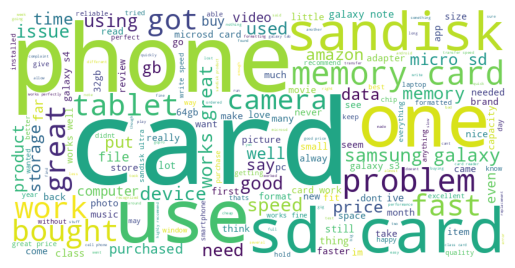

In [14]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
text = " ".join(df["Clean_Review"])
wc = WordCloud(width=800,
               height=400,
               background_color="white").generate(text)
plt.imshow(wc)
plt.axis("off")
plt.show()